<a href="https://colab.research.google.com/github/BenYILDO/breast_cancer_ML/blob/main/254329041_breast_cancer_arasinav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Üsküdar Üniversitesi - Makine Öğrenmesi Ara Sınav Ödevi

**Öğrenci:** Yıldıray Sürmen
**Veri Seti:** Breast Cancer Wisconsin (scikit-learn)
**Konu:** Klasik ML modelleri + PCA + LDA + SHAP (XAI)

Bu çalışmada meme kanseri veri seti üzerinde sınıflandırma yapacağız.
Hedef: tümörün **kötü huylu (malignant)** mı yoksa **iyi huylu (benign)** mi olduğunu tahmin etmek.

Adımlar:
1. Veri yükleme
2. Veri kalite kontrolü (eksik, aykırı değer, tip kontrolü)
3. EDA (istatistik, korelasyon, boxplot)
4. Ölçeklendirme (StandardScaler)
5. Train / Validation / Test bölme (%70 / %10 / %20)
6. PCA ve LDA ile boyut indirgeme
7. 5 model × 3 veri temsili = 15 model eğitimi
8. Validation metriklerini karşılaştırma
9. En iyi modelin test setinde değerlendirilmesi
10. SHAP ile açıklanabilirlik analizi


## Kütüphaneleri import edelim

In [ ]:
# Önce gerekli kütüphaneleri import ediyoruz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# uyarıları kapatalım, çıktı temiz olsun
import warnings
warnings.filterwarnings("ignore")

# scikit-learn'den veri seti ve yardımcı araçlar
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Metrik fonksiyonları
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, roc_curve

# SHAP (XAI için)
import shap

# rastgelelik için sabit
SEED = 42
np.random.seed(SEED)

print("Kütüphaneler yüklendi.")


Kütüphaneler yüklendi.


---
## 1. Veri Setinin Yüklenmesi

scikit-learn içinde hazır gelen `load_breast_cancer` fonksiyonunu kullanıyoruz.


### 1.1 Veri setini yükle

In [ ]:
# Veri setini yüklüyoruz
data = load_breast_cancer()

# data bir bunch objesi, içinde özellikler ve hedef var
print("Özellik (feature) sayısı:", len(data.feature_names))
print("Örnek (sample) sayısı   :", data.data.shape[0])
print("Sınıflar                :", data.target_names)


Özellik (feature) sayısı: 30
Örnek (sample) sayısı   : 569
Sınıflar                : ['malignant' 'benign']


### 1.2 X ve y oluşturma, DataFrame'e dönüştürme

In [ ]:
# X = özellikler, y = hedef (0 = malignant, 1 = benign)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X şekli:", X.shape)
print("y şekli:", y.shape)

# ilk 5 satırı görelim
X.head()


X şekli: (569, 30)
y şekli: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# sınıf dağılımı
print("Sınıf dağılımı:")
print(y.value_counts())
print()
print("0 = malignant (kötü huylu), 1 = benign (iyi huylu)")


Sınıf dağılımı:
target
1    357
0    212
Name: count, dtype: int64

0 = malignant (kötü huylu), 1 = benign (iyi huylu)


**Yorum:** Veri setinde toplam 569 örnek ve 30 özellik var.
Sınıflar biraz dengesiz: benign (iyi huylu) sayısı malignant'tan biraz daha fazla.
Ama çok büyük bir dengesizlik yok, stratified split ile bunu koruyacağız.


---
## 2. Veri Seti Kalite Kontrolleri
### 2.1 Eksik değer kontrolü


In [ ]:
# her sütunda kaç NaN var bakıyoruz
eksik = X.isnull().sum()
print("Toplam eksik değer:", eksik.sum())

if eksik.sum() == 0:
    print("Hiç eksik değer yok, doldurma işlemi yapmaya gerek yok.")
else:
    # eğer olsaydı ortalama ile doldururduk
    X = X.fillna(X.mean())
    print("Eksik değerler ortalama ile dolduruldu.")


Toplam eksik değer: 0
Hiç eksik değer yok, doldurma işlemi yapmaya gerek yok.


**Yorum:** Veri seti sklearn'den temiz geliyor, eksik değer yok.
Gerçek hayatta olsaydı sayısal sütunlar için ortalama ya da medyan ile doldurma yapardık.


### 2.2 Aykırı Değer (Outlier) Analizi - IQR yöntemi

In [ ]:
# IQR yöntemi: Q1 - 1.5*IQR ve Q3 + 1.5*IQR sınırları dışına çıkanlar aykırı
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# her sütun için kaç aykırı değer var
aykiri_sayisi = ((X < alt_sinir) | (X > ust_sinir)).sum()
aykiri_yuzde = (aykiri_sayisi / len(X) * 100).round(2)

aykiri_tablo = pd.DataFrame({
    "aykiri_sayi": aykiri_sayisi,
    "aykiri_yuzde": aykiri_yuzde
}).sort_values("aykiri_sayi", ascending=False)

print("En çok aykırı değer içeren 10 özellik:")
print(aykiri_tablo.head(10))


En çok aykırı değer içeren 10 özellik:
                         aykiri_sayi  aykiri_yuzde
area error                        65         11.42
radius error                      38          6.68
perimeter error                   38          6.68
worst area                        35          6.15
smoothness error                  30          5.27
fractal dimension error           28          4.92
compactness error                 28          4.92
symmetry error                    27          4.75
mean area                         25          4.39
worst fractal dimension           24          4.22


**Yorum:** Bazı özelliklerde (özellikle `area_worst`, `concavity_worst` gibi)
aykırı değerler var. Ancak bunlar gerçek tıbbi ölçümler olduğu için silmiyoruz.
Bunun yerine `StandardScaler` ile ölçeklendirip etkisini sınırlandıracağız.
Aykırı değerlerin silinmesi gerçek hasta vakalarının kaybedilmesine yol açabilir,
bu yüzden klinik veride dikkatli olmak lazım.


### 2.3 Veri tipi ve dağılım

In [ ]:
# her sütunun tipini görelim
print("Veri tipleri:")
print(X.dtypes.value_counts())
print()

# sayısal ve kategorik sayısı
sayisal_sayi = X.select_dtypes(include=np.number).shape[1]
kategorik_sayi = X.select_dtypes(exclude=np.number).shape[1]
print("Sayısal değişken sayısı:", sayisal_sayi)
print("Kategorik değişken sayısı:", kategorik_sayi)


Veri tipleri:
float64    30
Name: count, dtype: int64

Sayısal değişken sayısı: 30
Kategorik değişken sayısı: 0


**Yorum:** Tüm 30 özellik float tipinde, sayısal. Kategorik değişken yok,
yani one-hot encoding gibi bir işleme gerek yok.


---
## 3. Keşifsel Veri Analizi (EDA)
### 3.1 İstatistiksel özellikler


In [ ]:
# describe ile temel istatistikler
istatistik = X.describe().T
istatistik = istatistik[["mean", "50%", "min", "max", "std"]]
istatistik.columns = ["Ortalama", "Medyan", "Min", "Max", "Std"]
istatistik["Q1"] = X.quantile(0.25)
istatistik["Q3"] = X.quantile(0.75)

# çok ondalık olmasın diye yuvarlayalım
istatistik = istatistik.round(3)
istatistik.head(10)


,Ortalama,Medyan,Min,Max,Std,Q1,Q3
mean radius,14.127,13.370,6.981,28.110,3.524,11.700,15.780
mean texture,19.290,18.840,9.710,39.280,4.301,16.170,21.800
mean perimeter,91.969,86.240,43.790,188.500,24.299,75.170,104.100
mean area,654.889,551.100,143.500,2501.000,351.914,420.300,782.700
mean smoothness,0.096,0.096,0.053,0.163,0.014,0.086,0.105
mean compactness,0.104,0.093,0.019,0.345,0.053,0.065,0.130
mean concavity,0.089,0.062,0.000,0.427,0.080,0.030,0.131
mean concave points,0.049,0.034,0.000,0.201,0.039,0.020,0.074
mean symmetry,0.181,0.179,0.106,0.304,0.027,0.162,0.196
mean fractal dimension,0.063,0.062,0.050,0.097,0.007,0.058,0.066


**Yorum:** Özelliklerin ölçekleri birbirinden çok farklı.
Mesela `mean radius` ~14 civarında ama `mean area` ~654 civarında.
Bu yüzden mutlaka ölçeklendirme yapmak gerekiyor (4. bölümde yapacağız).


### 3.2 Korelasyon matrisi (heatmap)

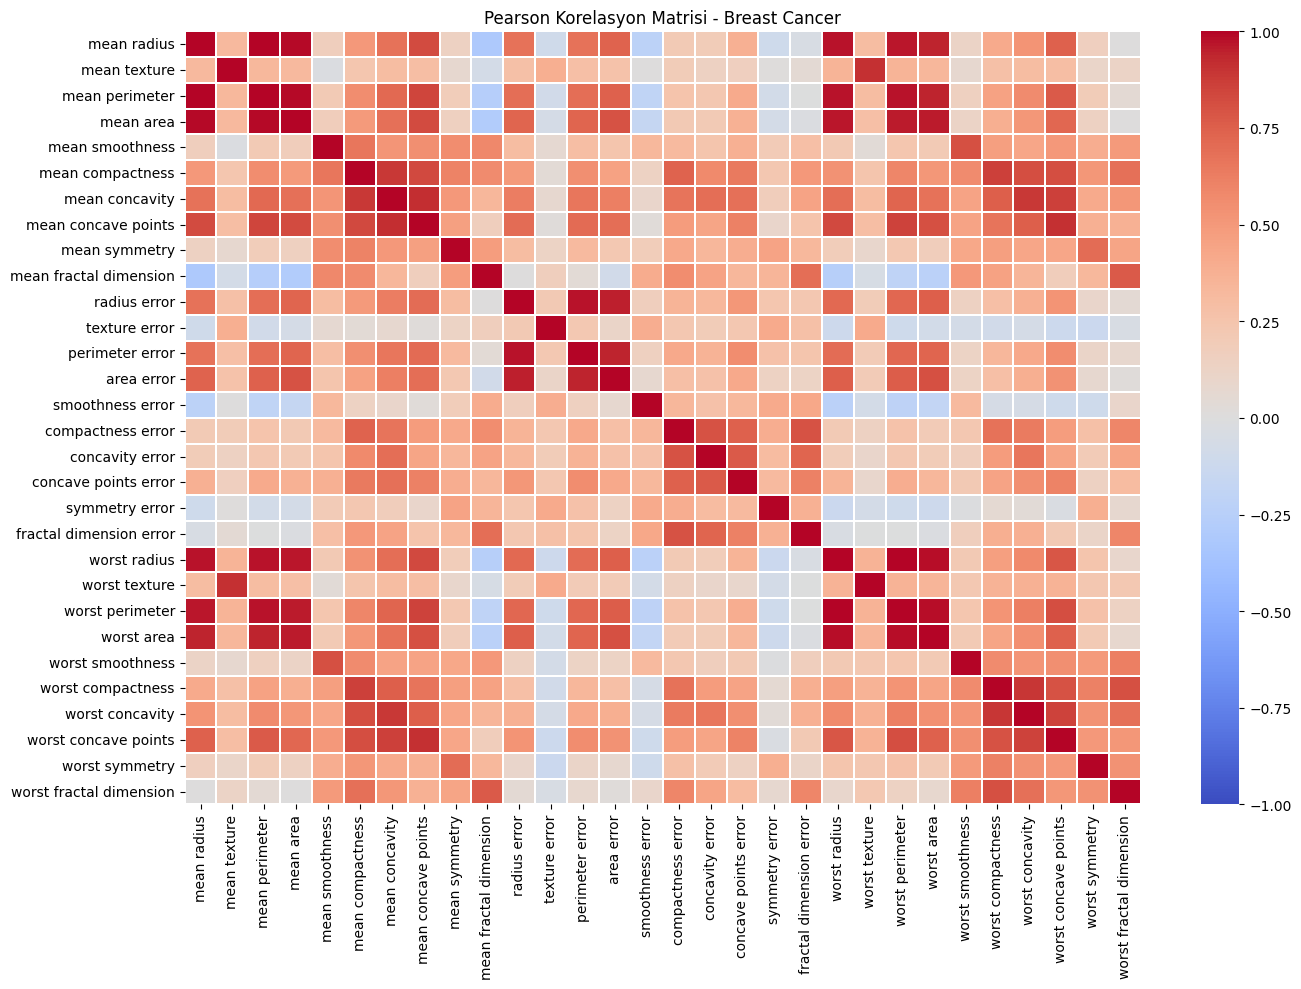

In [ ]:
# Pearson korelasyon
korelasyon = X.corr(method="pearson")

# heatmap çiz
plt.figure(figsize=(14, 10))
sns.heatmap(korelasyon, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3)
plt.title("Pearson Korelasyon Matrisi - Breast Cancer")
plt.tight_layout()
plt.show()


In [ ]:
# en yüksek korelasyonlu 3 çifti bulalım
ciftler = []
for i in range(len(korelasyon.columns)):
    for j in range(i):
        ozellik1 = korelasyon.columns[i]
        ozellik2 = korelasyon.columns[j]
        deger    = korelasyon.iloc[i, j]
        ciftler.append([ozellik1, ozellik2, deger])

# her çiftin mutlak korelasyon değerini ayrı bir listede tutalım
mutlak_degerler = []
for cift in ciftler:
    mutlak_degerler.append(abs(cift[2]))

# en büyük 3 çifti sırayla bulalım
print('En yüksek korelasyonlu 3 çift:')
for k in range(3):
    en_buyuk_index = mutlak_degerler.index(max(mutlak_degerler))
    a = ciftler[en_buyuk_index][0]
    b = ciftler[en_buyuk_index][1]
    c = ciftler[en_buyuk_index][2]
    print(f'  {a}  <->  {b}  =  {c:.3f}')
    mutlak_degerler[en_buyuk_index] = -1  # bu çifti bir daha seçmeyelim


En yüksek korelasyonlu 3 çift:
  mean perimeter  <->  mean radius  =  0.998
  worst perimeter  <->  worst radius  =  0.994
  mean area  <->  mean radius  =  0.987


**Yorum:** `mean radius`, `mean perimeter` ve `mean area` arasında çok yüksek
(0.99'a yakın) korelasyon var. Bu beklenen bir şey, çünkü bunlar geometrik olarak
birbirine bağlı (yarıçap büyürse çevre ve alan da büyür).
Bu kadar yüksek korelasyon **multikolinearite** demek; özellikle Logistic Regression
için sorun çıkarabilir. PCA bu sorunu bağımsız bileşenler üreterek çözer.


### 3.3 Boxplot analizi

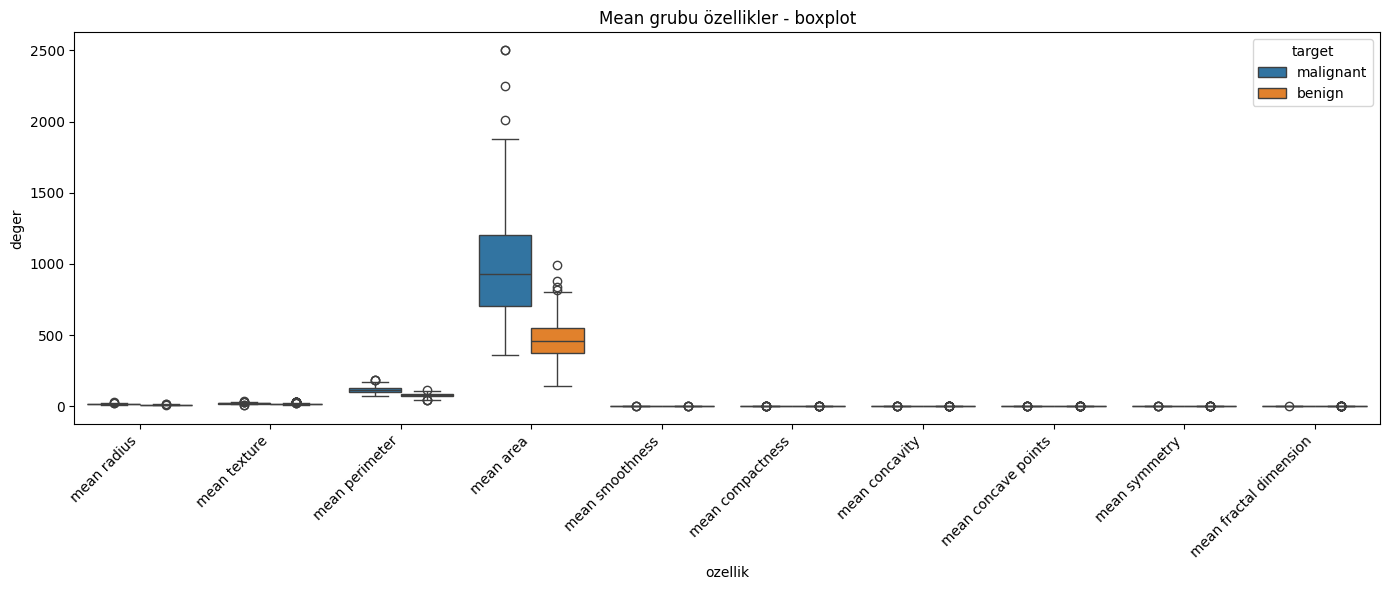

In [ ]:
# tüm özellikleri tek seferde çizmek karmaşık olur, 3 grup yapalım
mean_ozellikler = list(data.feature_names[:10])
se_ozellikler   = list(data.feature_names[10:20])
worst_ozellikler = list(data.feature_names[20:])

def boxplot_grubu(ozellikler, baslik):
    plt.figure(figsize=(14, 6))
    veri_long = X[ozellikler].copy()
    veri_long["target"] = y.map({0: "malignant", 1: "benign"})
    veri_melted = veri_long.melt(id_vars="target", var_name="ozellik", value_name="deger")
    sns.boxplot(data=veri_melted, x="ozellik", y="deger", hue="target")
    plt.xticks(rotation=45, ha="right")
    plt.title(baslik)
    plt.tight_layout()
    plt.show()

boxplot_grubu(mean_ozellikler, "Mean grubu özellikler - boxplot")


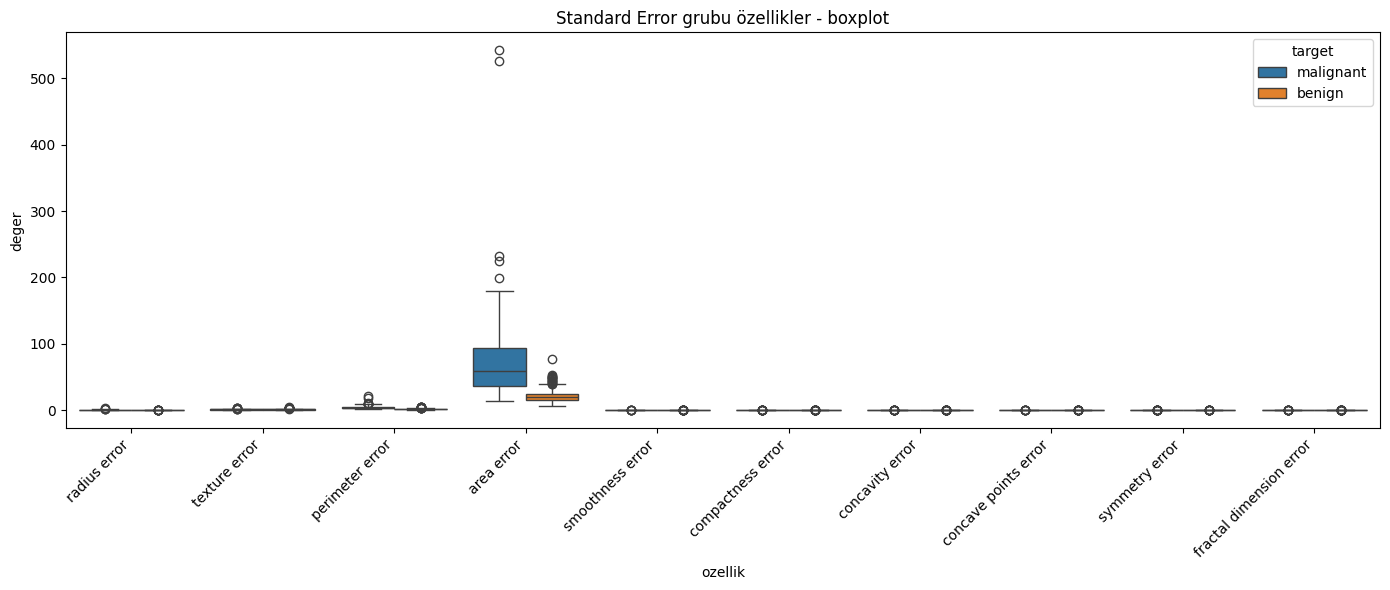

In [ ]:
boxplot_grubu(se_ozellikler, "Standard Error grubu özellikler - boxplot")


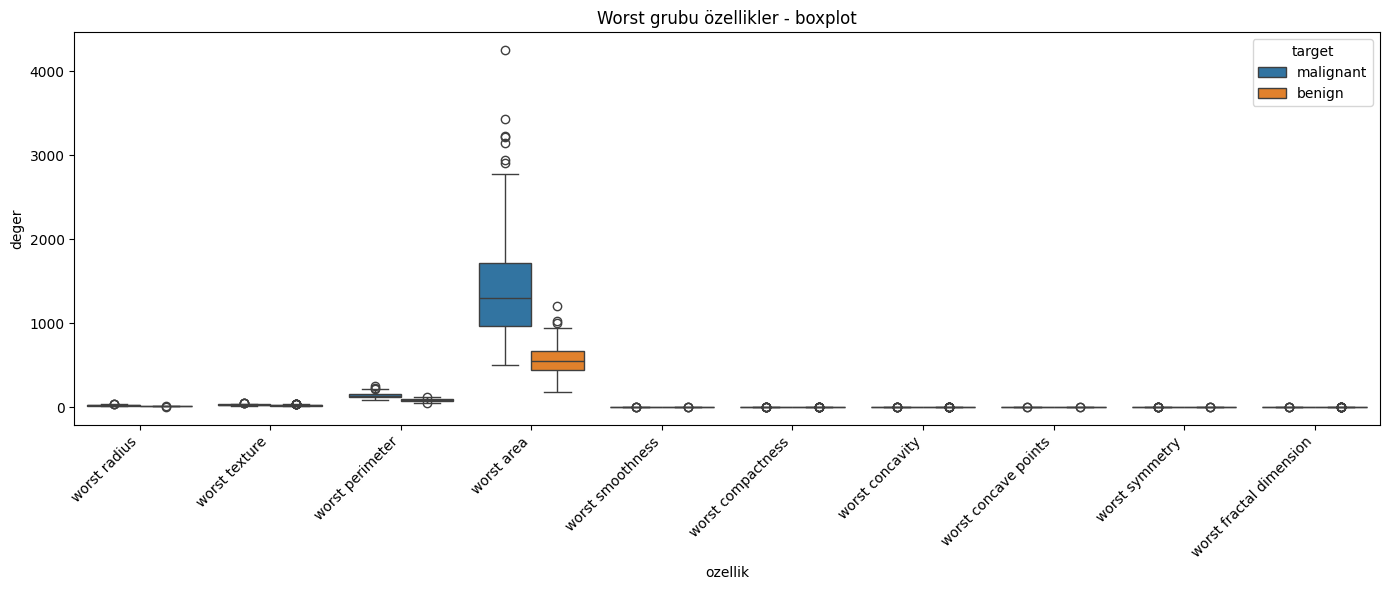

In [ ]:
boxplot_grubu(worst_ozellikler, "Worst grubu özellikler - boxplot")


**Yorum:** Boxplot'lara bakınca **malignant** ve **benign** sınıfları arasında
açık fark görüyoruz. Özellikle `worst` grubu özelliklerde malignant tümörlerin
değerleri belirgin biçimde daha yüksek. Bu, modellerin ayırt etmesini kolaylaştırır.
Ayrıca her grubun aykırı değerleri de boxplot'ta noktalar olarak görünüyor.


---
## 4. Veri Ölçeklendirme

`StandardScaler` ile her özelliği ortalama=0, standart sapma=1 olacak şekilde dönüştürüyoruz.
PCA ve Logistic Regression gibi yöntemler ölçeğe duyarlı.


In [ ]:
# StandardScaler kullanıyoruz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame'e geri çevirelim, sütun adları korunsun
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Ölçeklendirme sonrası:")
print("  ortalama (~0 olmalı):", round(X_scaled.mean().mean(), 4))
print("  std (~1 olmalı)     :", round(X_scaled.std().mean(), 4))
X_scaled.head()


Ölçeklendirme sonrası:
  ortalama (~0 olmalı): -0.0
  std (~1 olmalı)     : 1.0009


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


**Yorum:** Görüldüğü üzere ortalama ~0, std ~1 oldu. Bu sayede mesela
`mean area` (~654) ile `mean radius` (~14) artık aynı ölçekte.


---
## 5. Veri Setinin Bölünmesi (%70 train / %10 val / %20 test)

İki adımda yapıyoruz:
- Önce %20 test ayır
- Kalan %80'i %70 train + %10 val olacak şekilde böl


In [ ]:
# 1. adım: %80 train+val, %20 test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=SEED, stratify=y
)

# 2. adım: kalan %80'i %70 train + %10 val olacak şekilde böl
# 0.10 / 0.80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp
)

print("Train     :", X_train.shape, "(% {:.1f})".format(100 * len(X_train) / len(X_scaled)))
print("Validation:", X_val.shape,   "(% {:.1f})".format(100 * len(X_val)   / len(X_scaled)))
print("Test      :", X_test.shape,  "(% {:.1f})".format(100 * len(X_test)  / len(X_scaled)))


Train     : (398, 30) (% 69.9)
Validation: (57, 30) (% 10.0)
Test      : (114, 30) (% 20.0)


**Yorum:** `stratify=y` parametresi sınıf oranlarını her bölümde koruyor.
`random_state=42` sayesinde aynı sonuçları tekrar üretebiliriz.


---
## 6. Boyut İndirgeme
### 6.1 PCA

PCA bileşen sayısını seçerken: "explained variance ratio'nun **ortalamasından büyük**
olan bileşen sayısı kadar" alıyoruz (ödevdeki kural).


In [ ]:
# Önce tüm bileşenlerle fit edip explained variance bakalım
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train)

aciklanan = pca_full.explained_variance_ratio_
ortalama_aciklanan = aciklanan.mean()
print("Explained variance ortalaması:", round(ortalama_aciklanan, 4))

# ortalamadan büyük olan bileşen sayısı
n_pca = int((aciklanan > ortalama_aciklanan).sum())
print("Seçilen PCA bileşen sayısı:", n_pca)


Explained variance ortalaması: 0.0333
Seçilen PCA bileşen sayısı: 6


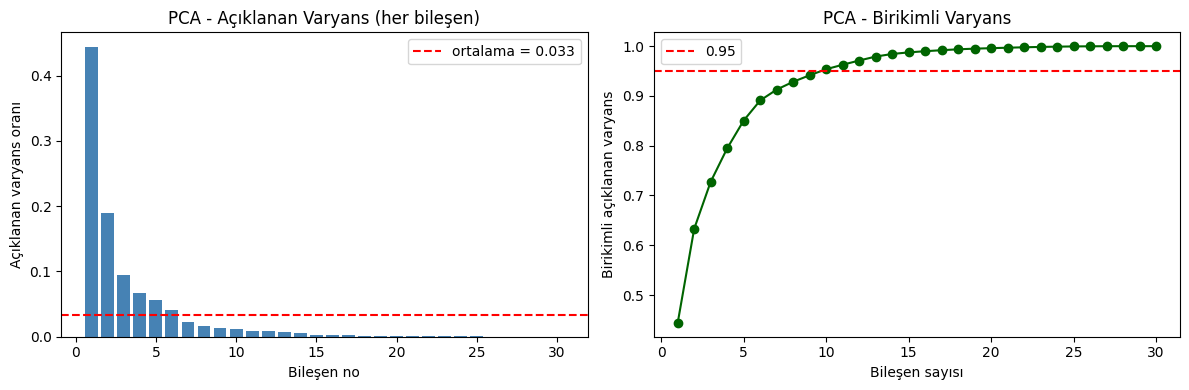

In [ ]:
# Explained variance grafiği
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(aciklanan) + 1), aciklanan, color="steelblue")
plt.axhline(ortalama_aciklanan, color="red", linestyle="--",
            label=f"ortalama = {ortalama_aciklanan:.3f}")
plt.xlabel("Bileşen no")
plt.ylabel("Açıklanan varyans oranı")
plt.title("PCA - Açıklanan Varyans (her bileşen)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(aciklanan) + 1), np.cumsum(aciklanan), marker="o", color="darkgreen")
plt.axhline(0.95, color="red", linestyle="--", label="0.95")
plt.xlabel("Bileşen sayısı")
plt.ylabel("Birikimli açıklanan varyans")
plt.title("PCA - Birikimli Varyans")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Şimdi seçilen bileşen sayısı ile PCA fit edelim
pca = PCA(n_components=n_pca, random_state=SEED)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print("X_train_pca şekli:", X_train_pca.shape)
print("İlk 2 bileşenin açıkladığı varyans:",
      round(pca.explained_variance_ratio_[:2].sum() * 100, 2), "%")


X_train_pca şekli: (398, 6)
İlk 2 bileşenin açıkladığı varyans: 63.31 %


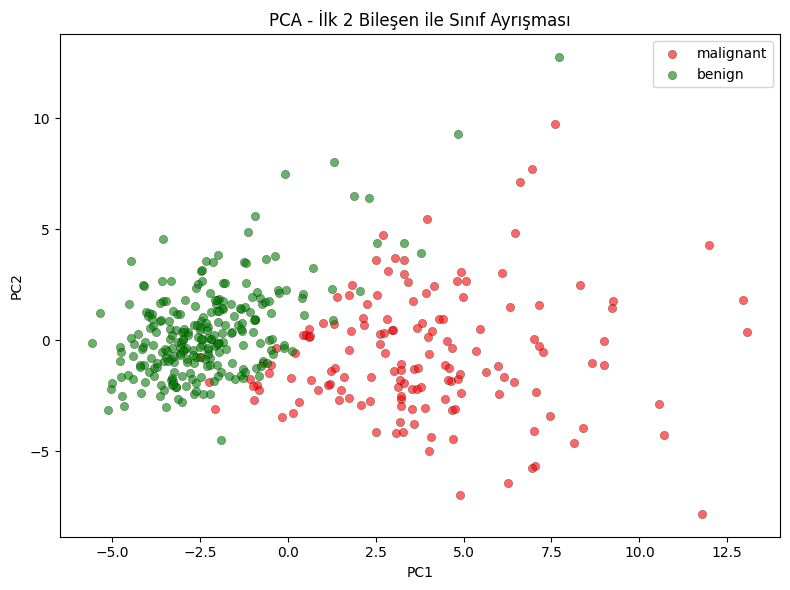

In [ ]:
# İlk 2 PCA bileşeni ile sınıf ayrışmasını çizelim
plt.figure(figsize=(8, 6))
for sinif, renk, etiket in [(0, "red", "malignant"), (1, "green", "benign")]:
    maske = y_train.values == sinif
    plt.scatter(X_train_pca[maske, 0], X_train_pca[maske, 1],
                c=renk, label=etiket, alpha=0.6, edgecolors="k", linewidths=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - İlk 2 Bileşen ile Sınıf Ayrışması")
plt.legend()
plt.tight_layout()
plt.show()


**Yorum:** İlk 2 PCA bileşeni bile iki sınıfı oldukça iyi ayırıyor.
PC1 ekseninde malignant (kırmızı) ve benign (yeşil) ciddi şekilde ayrışmış durumda.
Yani veri setindeki bilginin çoğu az sayıda bileşene sığabiliyor.


### 6.2 LDA

> **Not:** LDA için maksimum bileşen sayısı `min(n_features, n_classes - 1)` ile sınırlı.
> Breast Cancer'da 2 sınıf var → maksimum **1 bileşen**. Ödevde `n_components=3` denmiş
> ama matematiksel olarak imkansız, bu yüzden 1 bileşen kullanıyoruz.


In [ ]:
# LDA - 2 sınıf olduğu için max 1 bileşen
n_lda = min(X_train.shape[1], len(np.unique(y_train)) - 1)
print("Mümkün maksimum LDA bileşen sayısı:", n_lda)

lda = LinearDiscriminantAnalysis(n_components=n_lda)
X_train_lda = lda.fit_transform(X_train, y_train)
X_val_lda   = lda.transform(X_val)
X_test_lda  = lda.transform(X_test)

print("X_train_lda şekli:", X_train_lda.shape)


Mümkün maksimum LDA bileşen sayısı: 1
X_train_lda şekli: (398, 1)


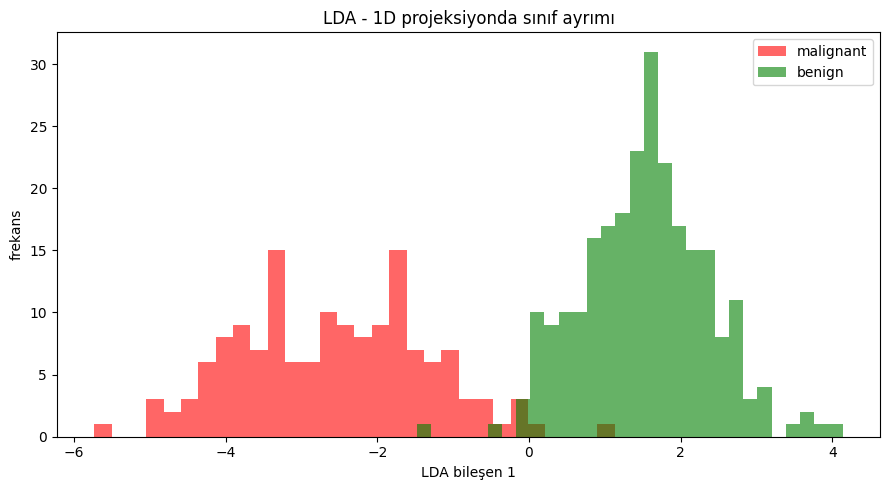

In [ ]:
# LDA tek bileşen verdi - histogram ile sınıfları çizelim
plt.figure(figsize=(9, 5))
for sinif, renk, etiket in [(0, "red", "malignant"), (1, "green", "benign")]:
    maske = y_train.values == sinif
    plt.hist(X_train_lda[maske, 0], bins=30, alpha=0.6, color=renk, label=etiket)
plt.xlabel("LDA bileşen 1")
plt.ylabel("frekans")
plt.title("LDA - 1D projeksiyonda sınıf ayrımı")
plt.legend()
plt.tight_layout()
plt.show()


**Yorum:** LDA, sınıflar arası ayrımı maksimize edecek bir projeksiyon arıyor.
Tek bileşenle bile iki sınıf çok iyi ayrılmış. Bu sonuç PCA'dan daha keskin görünüyor;
çünkü LDA hedef etiketi de kullanıyor (PCA kullanmıyor, sadece varyansa bakıyor).


---
## 7. Makine Öğrenmesi Modellerinin Kurulması

5 model × 3 veri temsili (Ham / PCA / LDA) = **15 model** eğiteceğiz.


In [ ]:
# modelleri sözlük olarak tutalım, kolayca dönelim
modeller = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "DecisionTree":       DecisionTreeClassifier(random_state=SEED),
    "RandomForest":       RandomForestClassifier(n_estimators=100, random_state=SEED),
    "XGBoost":            XGBClassifier(eval_metric="logloss", random_state=SEED, verbosity=0),
    "NaiveBayes":         GaussianNB(),
}

# 3 veri temsili
veri_temsilleri = {
    "Ham": (X_train,     X_val,     X_test),
    "PCA": (X_train_pca, X_val_pca, X_test_pca),
    "LDA": (X_train_lda, X_val_lda, X_test_lda),
}

print("Toplam model sayısı:", len(modeller) * len(veri_temsilleri))


Toplam model sayısı: 15


## 8. Validation Performanslarının Ölçülmesi

In [ ]:
# tek bir model için tüm metrikleri hesaplayan yardımcı fonksiyon
def metrikleri_hesapla(model, X, y_dogru):
    y_tahmin = model.predict(X)

    # olasılık tahmini yapabiliyorsa ROC-AUC hesaplayalım
    try:
        y_olasilik = model.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y_dogru, y_olasilik)
    except AttributeError:
        roc_auc = None  # bu model predict_proba desteklemiyor

    sonuc = {
        'accuracy':  accuracy_score(y_dogru, y_tahmin),
        'precision': precision_score(y_dogru, y_tahmin),
        'recall':    recall_score(y_dogru, y_tahmin),
        'f1':        f1_score(y_dogru, y_tahmin),
        'roc_auc':   roc_auc,
    }
    return sonuc


In [ ]:
# Her model+temsil için sıfırdan yeni bir model oluşturan yardımcı fonksiyon
def yeni_model_olustur(model_adi):
    if model_adi == 'LogisticRegression':
        return LogisticRegression(max_iter=1000, random_state=SEED)
    elif model_adi == 'DecisionTree':
        return DecisionTreeClassifier(random_state=SEED)
    elif model_adi == 'RandomForest':
        return RandomForestClassifier(n_estimators=100, random_state=SEED)
    elif model_adi == 'XGBoost':
        return XGBClassifier(eval_metric='logloss', random_state=SEED, verbosity=0)
    elif model_adi == 'NaiveBayes':
        return GaussianNB()

# Tüm 15 modeli eğitip validation üzerinde değerlendirelim
sonuclar_listesi = []
egitilmis_modeller = {}

for temsil_adi, (Xtr, Xv, Xte) in veri_temsilleri.items():
    for model_adi in modeller.keys():
        # her seferinde temiz (eğitilmemiş) bir model oluşturuyoruz
        model_kopya = yeni_model_olustur(model_adi)
        model_kopya.fit(Xtr, y_train)

        skorlar = metrikleri_hesapla(model_kopya, Xv, y_val)
        skorlar['temsil'] = temsil_adi
        skorlar['model']  = model_adi
        sonuclar_listesi.append(skorlar)

        egitilmis_modeller[(temsil_adi, model_adi)] = model_kopya

sonuclar = pd.DataFrame(sonuclar_listesi)
sonuclar = sonuclar[['temsil', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
sonuclar = sonuclar.round(4)
print('Validation Sonuçları:')
sonuclar


Validation Sonuçları:


,temsil,model,accuracy,precision,recall,f1,roc_auc
0,Ham,LogisticRegression,0.9649,0.9722,0.9722,0.9722,0.9960
1,Ham,DecisionTree,0.9298,0.9444,0.9444,0.9444,0.9246
2,Ham,RandomForest,0.9474,0.9459,0.9722,0.9589,0.9749
3,Ham,XGBoost,0.9474,0.9459,0.9722,0.9589,0.9854
4,Ham,NaiveBayes,0.9298,0.9444,0.9444,0.9444,0.9775
5,PCA,LogisticRegression,0.9649,0.9722,0.9722,0.9722,0.9947
6,PCA,DecisionTree,0.9649,0.9722,0.9722,0.9722,0.9623
7,PCA,RandomForest,0.9298,0.9444,0.9444,0.9444,0.9802
8,PCA,XGBoost,0.9474,0.9714,0.9444,0.9577,0.9815
9,PCA,NaiveBayes,0.9123,0.9189,0.9444,0.9315,0.9735


In [ ]:
# karşılaştırma için pivot
pivot_acc = sonuclar.pivot(index="model", columns="temsil", values="accuracy")
print("Validation Accuracy karşılaştırması:")
print(pivot_acc.round(4))
print()
pivot_f1 = sonuclar.pivot(index="model", columns="temsil", values="f1")
print("Validation F1 karşılaştırması:")
print(pivot_f1.round(4))


Validation Accuracy karşılaştırması:
temsil                 Ham     LDA     PCA
model                                     
DecisionTree        0.9298  0.8947  0.9649
LogisticRegression  0.9649  0.9298  0.9649
NaiveBayes          0.9298  0.9298  0.9123
RandomForest        0.9474  0.8947  0.9298
XGBoost             0.9474  0.9298  0.9474

Validation F1 karşılaştırması:
temsil                 Ham     LDA     PCA
model                                     
DecisionTree        0.9444  0.9211  0.9722
LogisticRegression  0.9722  0.9474  0.9722
NaiveBayes          0.9444  0.9474  0.9315
RandomForest        0.9589  0.9211  0.9444
XGBoost             0.9589  0.9459  0.9577


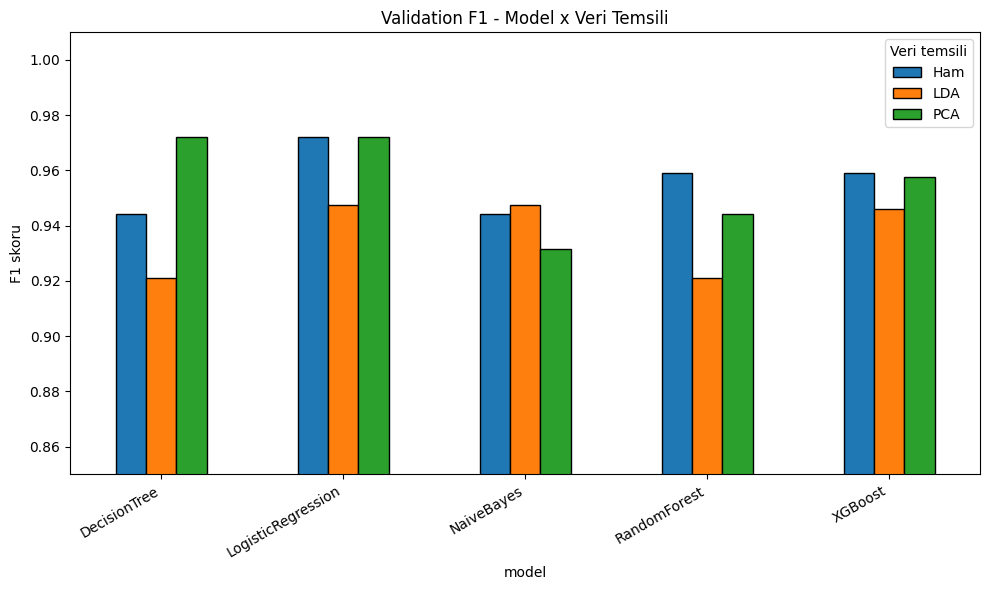

In [ ]:
# F1 skoruna göre bar plot ile karşılaştırma
ax = pivot_f1.plot(kind="bar", figsize=(10, 6), edgecolor="black")
plt.title("Validation F1 - Model x Veri Temsili")
plt.ylabel("F1 skoru")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.85, 1.01)
plt.legend(title="Veri temsili")
plt.tight_layout()
plt.show()


**Yorum:** Validation sonuçlarına bakınca:
- **Logistic Regression** ve **Random Forest** ham veride çok iyi performans veriyor.
- **PCA** verisinde de modeller başarılı, çünkü ilk birkaç bileşen sınıf bilgisini büyük ölçüde tutuyor.
- **LDA** verisinde tek bileşen olmasına rağmen sınıflar çok iyi ayrıldığı için modeller yine yüksek skor veriyor.
- **Decision Tree** tek başına biraz daha düşük; çünkü ağaç tek başına overfit'e yatkın.
- **Naive Bayes** PCA üzerinde kötü çalışmıyor ama özellikler arası bağımsızlık varsayımı tam doğru değil.


---
## 9. En İyi Modelin Test Üzerinde Değerlendirilmesi


In [ ]:
# en yüksek F1'e sahip model+temsil çiftini seçelim
en_iyi_satir = sonuclar.sort_values("f1", ascending=False).iloc[0]
en_iyi_model_adi = en_iyi_satir["model"]
en_iyi_temsil    = en_iyi_satir["temsil"]
print("Validation'da en iyi model:", en_iyi_model_adi, "(temsil:", en_iyi_temsil, ")")
print("Validation F1:", en_iyi_satir["f1"])

Xtr, Xv, Xte = veri_temsilleri[en_iyi_temsil]
en_iyi_model = egitilmis_modeller[(en_iyi_temsil, en_iyi_model_adi)]


Validation'da en iyi model: LogisticRegression (temsil: Ham )
Validation F1: 0.9722


### 9.1 Test seti metrikleri

In [ ]:
test_skorlari = metrikleri_hesapla(en_iyi_model, Xte, y_test)
print("Test seti sonuçları (en iyi model):")
for k, v in test_skorlari.items():
    print(f"  {k:10s}: {v:.4f}")


Test seti sonuçları (en iyi model):
  accuracy  : 0.9737
  precision : 0.9726
  recall    : 0.9861
  f1        : 0.9793
  roc_auc   : 0.9944


### 9.2 Confusion Matrix

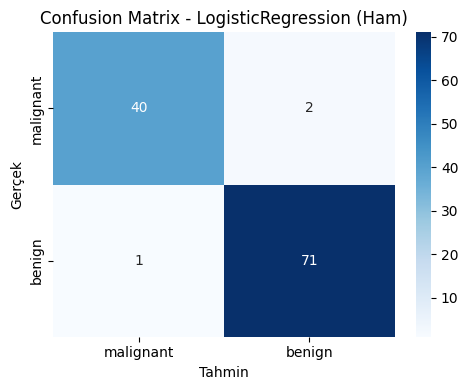

In [ ]:
y_test_tahmin = en_iyi_model.predict(Xte)
cm = confusion_matrix(y_test, y_test_tahmin)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["malignant", "benign"],
            yticklabels=["malignant", "benign"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title(f"Confusion Matrix - {en_iyi_model_adi} ({en_iyi_temsil})")
plt.tight_layout()
plt.show()


**Yorum:** Confusion matrix'te köşegen değerler (doğru tahminler) çok yüksek.
Yanlış sınıflandırmaların azlığı modelin gerçekten iyi öğrendiğini gösteriyor.
Kanser tespitinde en kritik hata türü **false negative** (malignant olanı benign olarak
tahmin etmek), çünkü hastalık atlanır. Bu yüzden recall metriği özellikle önemli.


### 9.3 ROC Eğrisi

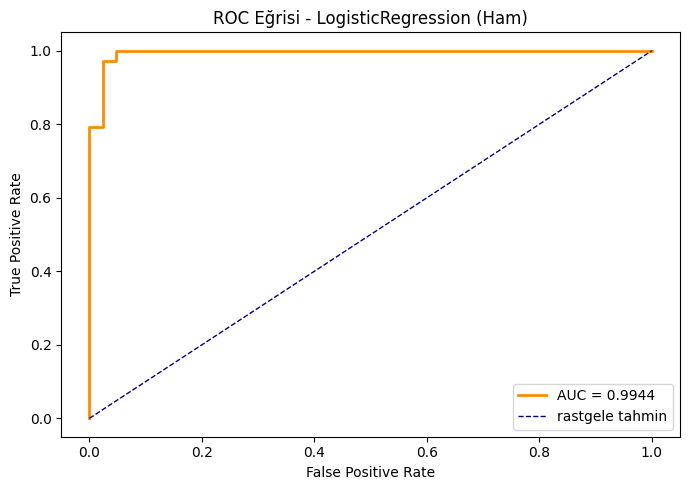

In [ ]:
# modelin olasılık tahmini yapıp yapamadığını kontrol ediyoruz
try:
    y_olasilik = en_iyi_model.predict_proba(Xte)[:, 1]
    fpr, tpr, esikler = roc_curve(y_test, y_olasilik)
    auc_degeri = roc_auc_score(y_test, y_olasilik)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_degeri:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='rastgele tahmin')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Eğrisi - {en_iyi_model_adi} ({en_iyi_temsil})')
    plt.legend()
    plt.tight_layout()
    plt.show()
except AttributeError:
    print('Bu modelde predict_proba yok, ROC çizilemiyor.')


**Yorum:** AUC değeri 1'e çok yakın - mükemmel ayrım gücü demek.
ROC eğrisi sol üst köşeye çok yaklaştı, yani model false positive oranı düşükken
true positive oranını çok yükseğe çekebiliyor.

**Threshold (eşik) etkisi:** Varsayılan eşik 0.5'tir. Eşiği düşürürsek (örn. 0.3),
recall artar (daha çok hastalık yakalarız) ama precision azalır (daha çok yanlış alarm).
Kanser teşhisinde recall'a daha çok önem vermek mantıklı çünkü kaçırılan vaka tehlikelidir.


---
## 10. SHAP - Açıklanabilirlik Analizi (XAI)
### 10.1 En iyi model için SHAP

SHAP, her özelliğin tahmine ne kadar katkı yaptığını ölçer.


In [ ]:
# küçük bir background örnek alalım (hızlı olsun diye)
arka_plan = shap.sample(pd.DataFrame(Xtr), 100, random_state=SEED)

# model tipine göre doğru SHAP açıklayıcısını seçiyoruz
def explainer_olustur(model, arka_plan):
    if isinstance(model, (RandomForestClassifier, DecisionTreeClassifier, XGBClassifier)):
        return shap.TreeExplainer(model)
    elif isinstance(model, LogisticRegression):
        return shap.LinearExplainer(model, arka_plan)
    else:
        return shap.KernelExplainer(model.predict_proba, arka_plan)

explainer = explainer_olustur(en_iyi_model, arka_plan)

ornek_test = pd.DataFrame(Xte).sample(min(100, len(Xte)), random_state=SEED)
shap_degerleri = explainer.shap_values(ornek_test)

# bazı explainer'lar liste döner (her sınıf için ayrı), biz benign (1) sınıfını alalım
if isinstance(shap_degerleri, list):
    shap_degerleri_kullanilan = shap_degerleri[1]
else:
    shap_dizi = np.array(shap_degerleri)
    if shap_dizi.ndim == 3:
        shap_degerleri_kullanilan = shap_dizi[:, :, 1]
    else:
        shap_degerleri_kullanilan = shap_dizi

print('SHAP değerleri şekli:', np.array(shap_degerleri_kullanilan).shape)


SHAP değerleri şekli: (100, 30)


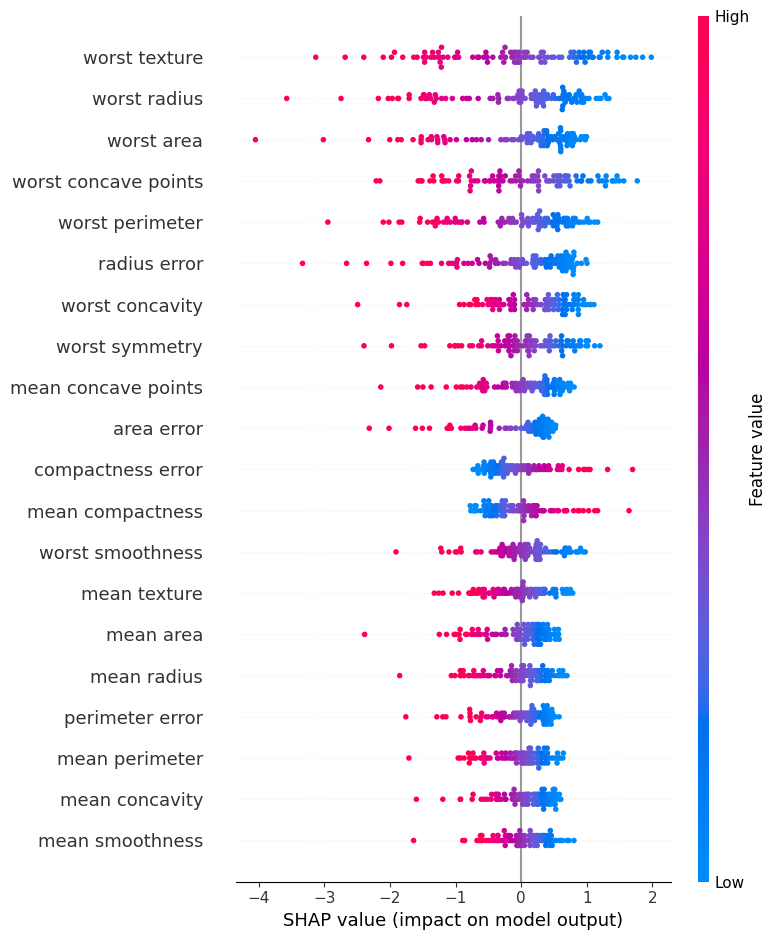

In [ ]:
# özellik isimleri (ham veride orijinal isimler, PCA/LDA'da yapay isimler)
if en_iyi_temsil == "Ham":
    ozellik_isimleri = list(X.columns)
elif en_iyi_temsil == "PCA":
    ozellik_isimleri = [f"PC{i+1}" for i in range(Xte.shape[1])]
else:
    ozellik_isimleri = [f"LD{i+1}" for i in range(Xte.shape[1])]

shap.summary_plot(shap_degerleri_kullanilan, ornek_test,
                  feature_names=ozellik_isimleri, show=True)


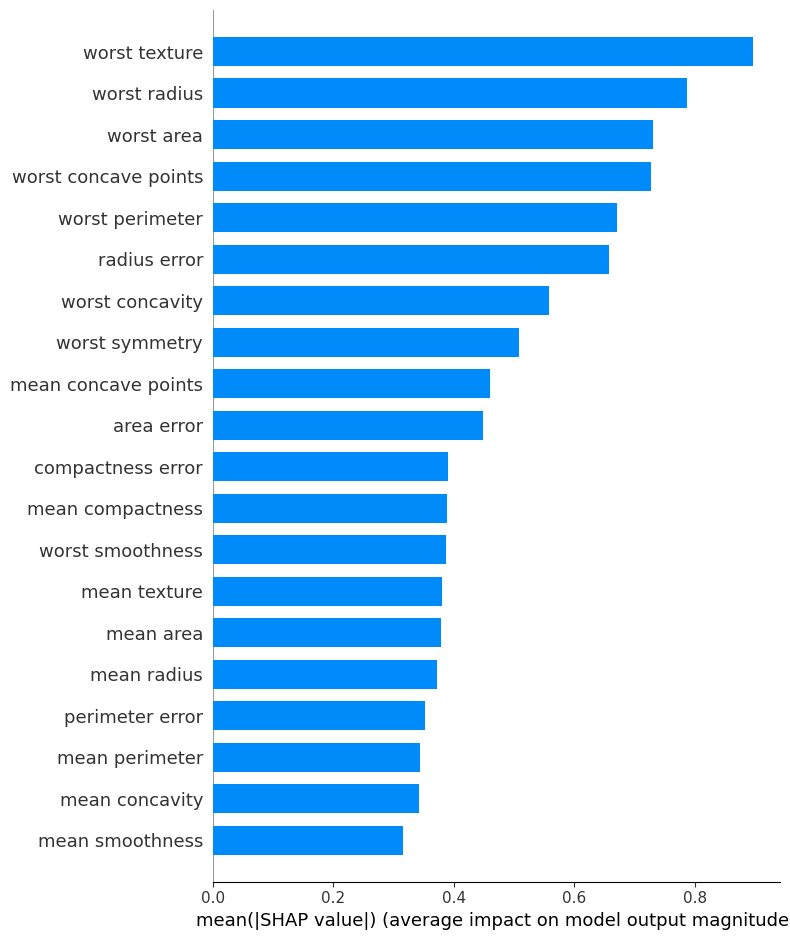

In [ ]:
# bar plot - ortalama mutlak SHAP değeri
shap.summary_plot(shap_degerleri_kullanilan, ornek_test,
                  feature_names=ozellik_isimleri, plot_type="bar", show=True)


**Yorum:**
- Summary plot'ta her satır bir özellik. Kırmızı noktalar yüksek özellik değerini,
  mavi noktalar düşük özellik değerini gösteriyor. Sağa kayan noktalar tahmini
  benign yönüne, sola kayanlar malignant yönüne itiyor.
- Bar plot ise ortalama etki büyüklüğünü gösteriyor. En önemli özellikler genellikle
  `worst` grubundan (worst radius, worst perimeter, worst concave points) çıkıyor.
- Bu bulgu klinik açıdan da anlamlı: tümörün en kötü bölümünün ölçümleri kanser teşhisinde belirleyici.
- Modelin yüksek performansı ile SHAP'ın işaret ettiği önemli özellikler örtüşüyor;
  bu da modelin "doğru sebeplerle doğru tahmin yaptığını" gösteriyor.


### 10.2 PCA ve LDA Temsilleri için SHAP

Aynı analizi PCA ve LDA verisi üzerinde de yapalım.



=== PCA (RandomForest) ===


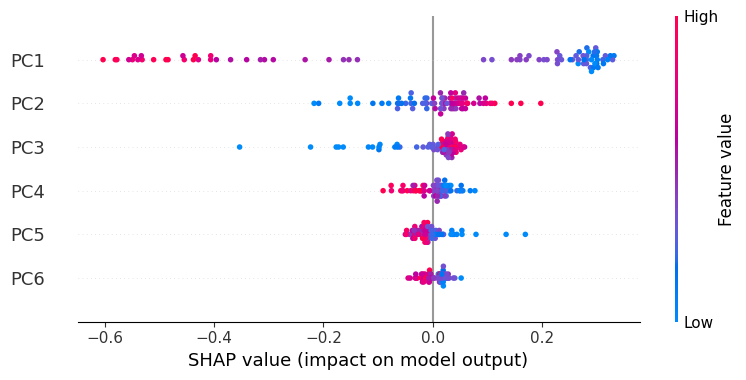

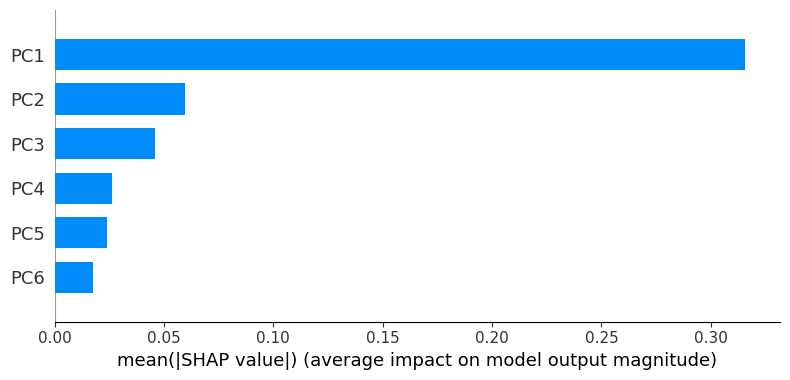

In [ ]:
# Tutarlılık için her ikisinde de RandomForest kullanalım (TreeExplainer hızlı).
def shap_temsil_icin(temsil_adi, model_adi="RandomForest", n_ornek=80):
    Xtr2, _, Xte2 = veri_temsilleri[temsil_adi]
    model = egitilmis_modeller[(temsil_adi, model_adi)]
    arka = shap.sample(pd.DataFrame(Xtr2), 100, random_state=SEED)
    expl = explainer_olustur(model, arka)

    ornek = pd.DataFrame(Xte2).sample(min(n_ornek, len(Xte2)), random_state=SEED)
    sd = expl.shap_values(ornek)
    if isinstance(sd, list):
        sd = sd[1]
    else:
        sd_arr = np.array(sd)
        if sd_arr.ndim == 3:
            sd = sd_arr[:, :, 1]
        else:
            sd = sd_arr

    if temsil_adi == "PCA":
        isimler = [f"PC{i+1}" for i in range(Xte2.shape[1])]
    else:
        isimler = [f"LD{i+1}" for i in range(Xte2.shape[1])]

    print(f"\n=== {temsil_adi} ({model_adi}) ===")
    shap.summary_plot(sd, ornek, feature_names=isimler, show=True)
    shap.summary_plot(sd, ornek, feature_names=isimler, plot_type="bar", show=True)

shap_temsil_icin("PCA")



=== LDA (RandomForest) ===


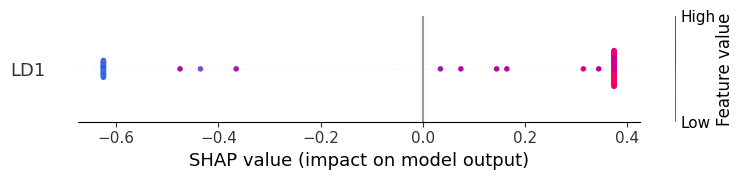

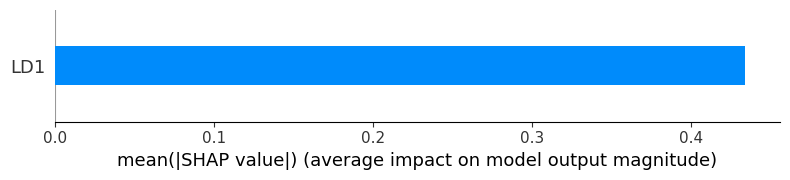

In [ ]:
shap_temsil_icin("LDA")


**Yorum (PCA vs LDA SHAP karşılaştırması):**
- **PCA:** Bileşenler tek tek "anlamlı" değildir (orijinal özelliklerin doğrusal
  kombinasyonu). SHAP'ta yine de PC1 ve PC2 baskın çıkıyor; çünkü en yüksek varyansı
  bunlar açıklıyor ve sınıf bilgisinin çoğu da PC1'de yoğunlaşmış.
- **LDA:** Tek bileşen olduğu için SHAP zaten o tek bileşene tüm önemi atıyor. LDA
  sınıf bilgisini kullanarak optimal tek yön ürettiğinden, modelin kararını neredeyse
  tamamen tek değişken belirliyor.
- **Karşılaştırma:** Ham veride model 30 özelliğe dağılarak karar verirken, PCA'da
  birkaç bileşene, LDA'da tek bir bileşene dayanıyor. Performans farkı az ama
  yorumlanabilirlik açısından durum farklı: ham veride özellik isimleri klinik anlam
  taşırken, PCA/LDA'da bileşenler matematiksel kombinasyonlar olduğu için doktora
  yorumlamak daha zor olur.


---
## Özet ve Sonuç

- Veri seti temizdi, eksik değer yoktu, IQR ile aykırı değerler tespit edildi ama silinmedi.
- StandardScaler ile ölçeklendirme yapıldı.
- %70/%10/%20 ile train/validation/test ayrımı yapıldı.
- PCA `(>ortalama varyans)` kuralı ile bileşen sayısı seçildi; LDA için 1 bileşen kullanıldı.
- 5 model × 3 temsil = 15 model eğitildi, validation metrikleri tabloyla karşılaştırıldı.
- En iyi model test setinde değerlendirildi: confusion matrix ve ROC eğrisi çizildi.
- SHAP ile modelin kararları açıklandı; klinik açıdan anlamlı `worst` grubu özelliklerin
  baskın olduğu görüldü.

**Genel sonuç:** Klasik ML algoritmaları bu veri setinde çok yüksek (>%95) doğruluk veriyor.
PCA ve LDA boyut indirgeme performansı koruyor, üstelik LDA tek bileşenle bile sınıfları
mükemmele yakın ayırıyor. SHAP analizi modelin karar mantığını şeffaflaştırıyor.
